Replaces the BPE / trigram-pair construction with **genuine 4-grams (tetragrams)**.

Pipeline: read Roman numerals from `*_functional.lab` → **normalize enharmonic spellings via the 12-tone mapping** (same `normalize_chord` as `forming_n_gram_datasets_ACE.ipynb` and `05_axe_chords.ipynb`) → drop consecutive duplicates → sliding window of 4 → window retention per the gate switch below.

In [1]:
import os, json
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = '/workspace/dataset'
COLLECTIONS = ['lastfm', 'suno', 'udio']
OUT_DIR = '/workspace/Figures'
N = 40  # rows per panel (matches notebook num=40)

# Distinctness gate, same switch as forming_n_gram_datasets_ACE.ipynb:
#   True  = legacy: keep a window only if >=3 of 4 chords distinct (case-insensitive)
#   False = keep every window after consecutive de-duplication, except windows
#           built from a single root (i I i I, iv IV iv IV, ...). Outputs get
#           the suffix _gate_false.
APPLY_DISTINCTNESS_GATE = False
GATE_SUFFIX = '' if APPLY_DISTINCTNESS_GATE else '_gate_false'

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# FONT — Fira Code for all plots in this notebook
# ═══════════════════════════════════════════════════════════════════════════════
plt.rcParams['font.family'] = 'Fira Code'
plt.rcParams['font.monospace'] = ['Fira Code']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Fira Code'
plt.rcParams['mathtext.it'] = 'Fira Code'
plt.rcParams['mathtext.bf'] = 'Fira Code'

In [3]:
# ---- Data loading (identical to notebook cell 3) ----
import re

# 12-TONE CHORD NORMALISER (identical to forming_n_gram_datasets_ACE.ipynb and
# 05_axe_chords.ipynb — keep in sync). Resolves enharmonic spellings to a
# canonical vocabulary, e.g. #V → bVI, #VII → I, ##IV → V, biv → iii.
_DEG_SEMI = {'I': 0, 'II': 2, 'III': 4, 'IV': 5, 'V': 7, 'VI': 9, 'VII': 11}
_SEMI_MAJ = {0:'I', 1:'bII', 2:'II', 3:'bIII', 4:'III', 5:'IV',
             6:'#IV', 7:'V', 8:'bVI', 9:'VI', 10:'bVII', 11:'VII'}
_SEMI_MIN = {0:'i', 1:'bii', 2:'ii', 3:'biii', 4:'iii', 5:'iv',
             6:'#iv', 7:'v', 8:'bvi', 9:'vi', 10:'bvii', 11:'vii'}
_CHORD_RE = re.compile(
    r'^([#b]*)(VII|VI|V|IV|III|II|I|vii|vi|v|iv|iii|ii|i)$')

def normalize_chord(ch):
    """Resolve enharmonics via 12-tone semitone mapping."""
    norm = re.sub(r'^B(?=[IViv])', 'b', ch)
    m = _CHORD_RE.match(norm)
    if not m:
        return ch
    acc_str, deg = m.group(1), m.group(2)
    acc = acc_str.count('#') - acc_str.count('b')
    is_minor = deg[0].islower()
    semi = (_DEG_SEMI[deg.upper()] + acc) % 12
    return _SEMI_MIN[semi] if is_minor else _SEMI_MAJ[semi]

for _inp, _exp in [('#V','bVI'), ('#VII','I'), ('#III','IV'), ('##IV','V'),
                   ('biv','iii'), ('BVII','bVII'), ('bVI','bVI'), ('I','I')]:
    assert normalize_chord(_inp) == _exp, (_inp, normalize_chord(_inp), _exp)


def parse_functional_lab(path):
    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'N':
                labels.append(normalize_chord(parts[2]))
    return labels

def load_chord_streams(collection_name):
    seqs = []
    root = os.path.join(BASE_DIR, collection_name)
    for song_id in os.listdir(root):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue
        tokens = parse_functional_lab(fp)
        if tokens:
            seqs.append(tokens)
    return seqs

# ---- Genuine tetragrams (make_ngram n=4) ----
def tetragrams_of_song(chords):
    filtered = []
    for i, c in enumerate(chords):
        if i == 0 or c != chords[i - 1]:
            filtered.append(c)
    out = []
    for i in range(len(filtered) - 3):
        w = tuple(filtered[i:i + 4])
        unique = len(set(x.lower() for x in w))
        if APPLY_DISTINCTNESS_GATE:
            if unique < 3:
                continue
        else:
            # Single-root window: only mode/case alternation, no real motion
            if unique == 1:
                continue
        out.append(w)
    return out

def tetragram_counts(collection_name):
    cnt = Counter()
    for chords in load_chord_streams(collection_name):
        cnt.update(tetragrams_of_song(chords))
    return cnt

print('functions defined (with 12-tone enharmonic normalization)')

functions defined (with 12-tone enharmonic normalization)


In [4]:
# ---- Count tetragrams per collection ----
tetra = {}
for col in COLLECTIONS:
    tetra[col] = tetragram_counts(col)
    print(f"{col}: {sum(tetra[col].values()):,} tetragrams, {len(tetra[col]):,} unique")

lastfm: 1,396,018 tetragrams, 92,167 unique
suno: 1,372,615 tetragrams, 54,928 unique
udio: 917,453 tetragrams, 76,145 unique


In [5]:
# ---- Cross-collection matrix ranked by a reference collection ----
def build_matrix(ref):
    top = [k for k, _ in tetra[ref].most_common(N)]
    labels, mat = [], []
    for w in top:
        labels.append('-'.join(w))  # all four chords, hyphen-separated (T-Type, matches paper)
        mat.append([tetra['lastfm'].get(w, 0),
                    tetra['suno'].get(w, 0),
                    tetra['udio'].get(w, 0)])
    return labels, np.array(mat), top

def plot_panel(ref, fname):
    labels, mat, top = build_matrix(ref)
    # ---- styling identical to original 07 notebook ----
    t_size = 18
    col_width_in = 2
    row_height_in = 0.25
    fig_w = col_width_in * len(COLLECTIONS) + 1.0
    fig_h = row_height_in * len(labels) + 2.0
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(mat, xticklabels=COLLECTIONS, yticklabels=labels,
                cmap='Greys', annot=True, fmt='.0f', linewidths=0.4, cbar=False)
    ax = plt.gca()
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)
    plt.ylabel('Tetragrams', fontsize=18)
    plt.tight_layout()
    os.makedirs(OUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUT_DIR, fname + '.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(OUT_DIR, fname + '.pdf'), bbox_inches='tight')
    plt.show()
    return labels, mat, top

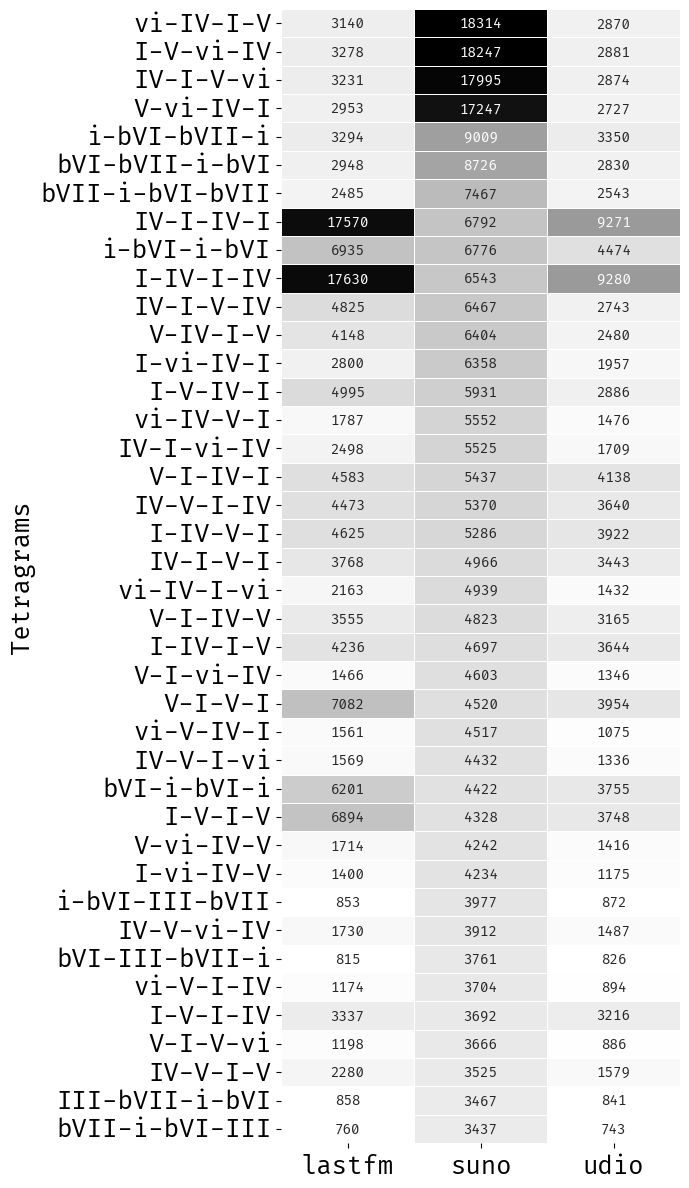

In [6]:
# ---- Suno-ranked panel (left) ----
suno_labels, suno_mat, suno_top = plot_panel('suno', f'tetragram_suno_ranked{GATE_SUFFIX}')

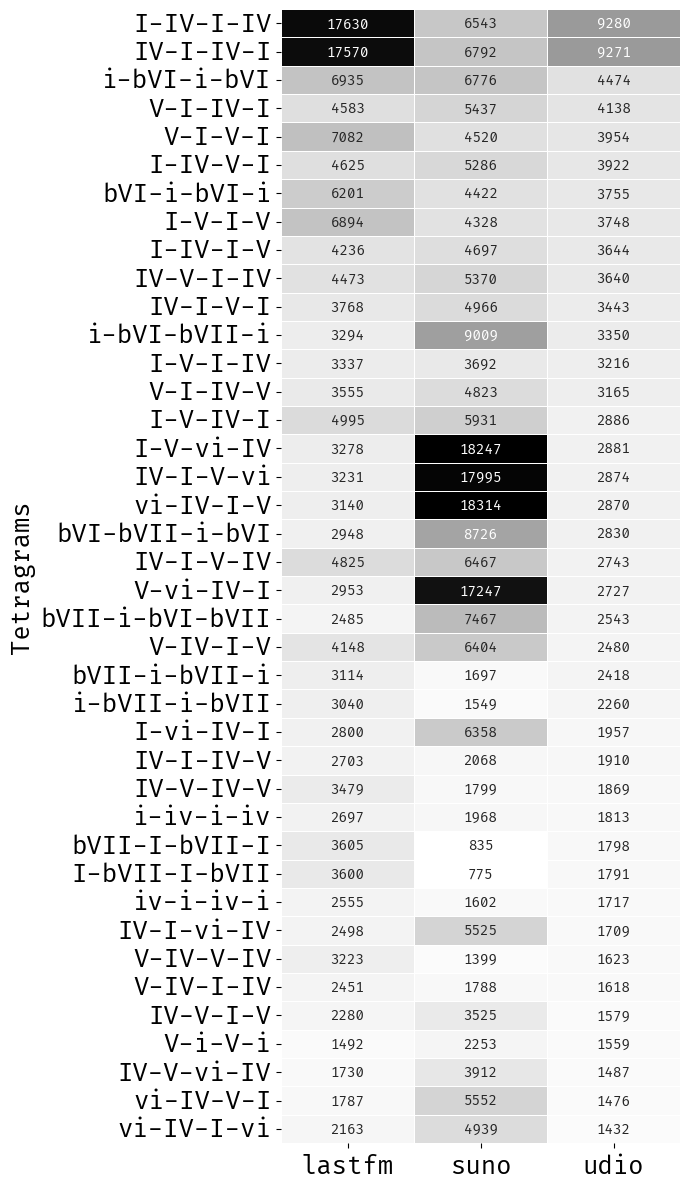

In [7]:
# ---- Udio-ranked panel (right) ----
udio_labels, udio_mat, udio_top = plot_panel('udio', f'tetragram_udio_ranked{GATE_SUFFIX}')

In [8]:
# ---- Cross-collection correlations on the full tetragram vocabulary ----
def corr(a, b):
    keys = set(tetra[a]) | set(tetra[b])
    va = np.array([tetra[a].get(k, 0) for k in keys])
    vb = np.array([tetra[b].get(k, 0) for k in keys])
    return float(np.corrcoef(va, vb)[0, 1])

corrs = {'lastfm-udio': corr('lastfm', 'udio'),
         'lastfm-suno': corr('lastfm', 'suno'),
         'suno-udio':   corr('suno', 'udio')}
for k, v in corrs.items():
    print(f"{k}: r = {v:.3f}")

lastfm-udio: r = 0.967
lastfm-suno: r = 0.662
suno-udio: r = 0.767


In [9]:
# ---- Dump numbers for the paper ----
def panel_dump(labels, mat):
    return [{"tetragram": lab, "lastfm": int(r[0]), "suno": int(r[1]), "udio": int(r[2])}
            for lab, r in zip(labels, mat)]

out = {"totals": {c: int(sum(tetra[c].values())) for c in COLLECTIONS},
       "unique": {c: int(len(tetra[c])) for c in COLLECTIONS},
       "correlations": corrs,
       "suno_ranked": panel_dump(suno_labels, suno_mat),
       "udio_ranked": panel_dump(udio_labels, udio_mat)}
with open(os.path.join(OUT_DIR, f'replication_numbers{GATE_SUFFIX}.json'), 'w') as f:
    json.dump(out, f, indent=2)

print('Suno-ranked top 15 (Lastfm / Suno / Udio):')
for row in out['suno_ranked'][:15]:
    print(f"  {row['tetragram']:<22} {row['lastfm']:>7} {row['suno']:>7} {row['udio']:>7}")

Suno-ranked top 15 (Lastfm / Suno / Udio):
  vi-IV-I-V                 3140   18314    2870
  I-V-vi-IV                 3278   18247    2881
  IV-I-V-vi                 3231   17995    2874
  V-vi-IV-I                 2953   17247    2727
  i-bVI-bVII-i              3294    9009    3350
  bVI-bVII-i-bVI            2948    8726    2830
  bVII-i-bVI-bVII           2485    7467    2543
  IV-I-IV-I                17570    6792    9271
  i-bVI-i-bVI               6935    6776    4474
  I-IV-I-IV                17630    6543    9280
  IV-I-V-IV                 4825    6467    2743
  V-IV-I-V                  4148    6404    2480
  I-vi-IV-I                 2800    6358    1957
  I-V-IV-I                  4995    5931    2886
  vi-IV-V-I                 1787    5552    1476
